<a href="https://colab.research.google.com/github/ElviraGD-lab/pajares-mountain-corridor-baseline/blob/main/notebooks/01_boundaries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Administrative boundaries — Asturias

Extracts the 78 concejos of Asturias from geoBoundaries ADM3 using DuckDB over
HTTP, without downloading the 2 GB source file.

Produces the study-area boundaries used by every other notebook in this project,
and writes a source passport recording provenance and licence.

**Site:** Puerto de Pajares lies inside the concejo of Lena. Pajares is a village
(*parroquia*) and does not exist at ADM3 level in any global dataset.


In [ ]:
%%capture
!pip install duckdb

In [ ]:
import os
from datetime import date, datetime, timezone

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
# Source: FieldMaps edge-matched geoBoundaries, ADM3 polygons.
# Chosen over Overture (division subtypes are not applied uniformly across
# countries) and over IGN (requires download rather than remote query).
# See docs/METHODOLOGY.md section 1.
ADM3_URL = 'https://data.fieldmaps.io/edge-matched/open/intl/adm3_polygons.parquet'

# Administrative levels in Spain:
#   adm1 = comunidad autonoma -> 'Principado de Asturias'
#   adm2 = provincia          -> 'Asturias' (uniprovincial: same territory)
#   adm3 = municipio          -> called 'concejos' in Asturias (78 of them)
REGION_ADM1 = 'Principado de Asturias'
COUNTRY_PREFIX = 'ESP'

STUDY_SITES = ['Lena']          # Pajares is a village inside this concejo
EXPECTED_CONCEJOS = 78
EXPECTED_AREA_KM2 = 10600       # published figure, for the sanity check

# EPSG:25830 = ETRS89 / UTM 30N, official CRS for mainland Spain.
# Area cannot be computed in degrees: the result would be in square degrees,
# which is not convertible to metric units, and no error would be raised.
CRS_MEASURE = 'EPSG:25830'
CRS_DELIVERY = 'EPSG:4326'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/asturias-grid-risk-ai'
DATA_FOLDER = os.path.join(PROJECT_ROOT, 'data', 'boundaries')
os.makedirs(DATA_FOLDER, exist_ok=True)

print(f'Output folder: {DATA_FOLDER}')

Mounted at /content/drive
Output folder: /content/drive/MyDrive/asturias-grid-risk-ai/data/boundaries


In [ ]:
con = duckdb.connect()
con.install_extension('spatial')
con.load_extension('spatial')

In [ ]:
# Inspect the schema before querying. Reads only the file header, not the data.
con.sql(f"DESCRIBE SELECT * FROM read_parquet('{ADM3_URL}')").df()

,column_name,column_type,null,key,default,extra
0,fid,BIGINT,YES,None,None,None
1,adm3_id,VARCHAR,YES,None,None,None
2,adm3_src,VARCHAR,YES,None,None,None
3,adm3_name,VARCHAR,YES,None,None,None
4,adm3_name1,VARCHAR,YES,None,None,None
5,adm3_name2,VARCHAR,YES,None,None,None
6,adm2_id,VARCHAR,YES,None,None,None
7,adm2_src,VARCHAR,YES,None,None,None
8,adm2_name,VARCHAR,YES,None,None,None
9,adm2_name1,VARCHAR,YES,None,None,None


In [ ]:
query = f'''
SELECT
    adm1_name,
    adm2_name,
    adm3_name,
    adm3_id,
    ST_AsWKB(geometry) AS geometry
FROM read_parquet('{ADM3_URL}')
WHERE
    adm1_id LIKE '{COUNTRY_PREFIX}%' AND
    adm1_name = '{REGION_ADM1}'
ORDER BY adm3_name
'''

concejos_df = con.sql(query).df()

# WKB carries no CRS information, so it must be declared explicitly.
concejos = gpd.GeoDataFrame(
    concejos_df,
    geometry=gpd.GeoSeries.from_wkb(concejos_df['geometry'].apply(bytes)),
    crs=CRS_DELIVERY,
)

concejos.head()

,adm1_name,adm2_name,adm3_name,adm3_id,geometry
0,Principado de Asturias,Asturias,Allande,ESP-20230119-18-1-001,"MULTIPOLYGON (((-6.78177 43.11298, -6.77742 43..."
1,Principado de Asturias,Asturias,Aller,ESP-20230119-18-1-002,"MULTIPOLYGON (((-5.42978 43.10536, -5.43081 43..."
2,Principado de Asturias,Asturias,Amieva,ESP-20230119-18-1-003,"MULTIPOLYGON (((-5.02257 43.23554, -5.02277 43..."
3,Principado de Asturias,Asturias,Avilés,ESP-20230119-18-1-004,"MULTIPOLYGON (((-5.90134 43.53903, -5.89973 43..."
4,Principado de Asturias,Asturias,Belmonte de Miranda,ESP-20230119-18-1-005,"MULTIPOLYGON (((-6.24686 43.19315, -6.24518 43..."


In [ ]:
# Check what came back, not only how many. A count alone would not catch a
# query returning the province instead of its municipalities.
n = len(concejos)
print(f'Features returned: {n}   (expected {EXPECTED_CONCEJOS})')

area_km2 = concejos.to_crs(CRS_MEASURE).area.sum() / 1e6
print(f'Total area: {area_km2:.0f} km2   (published figure ~{EXPECTED_AREA_KM2})')

for name in STUDY_SITES + ['Oviedo', 'Cabrales']:
    found = concejos['adm3_name'].str.contains(name, case=False).any()
    print(f'{name}: {"found" if found else "NOT FOUND"}')

assert n == EXPECTED_CONCEJOS, f'Expected {EXPECTED_CONCEJOS} concejos, got {n}'
assert abs(area_km2 - EXPECTED_AREA_KM2) < 500, 'Area departs from the published figure'
print('\nChecks passed.')

Features returned: 78   (expected 78)
Total area: 10601 km2   (published figure ~10600)
Lena: found
Oviedo: found
Cabrales: found

Checks passed.


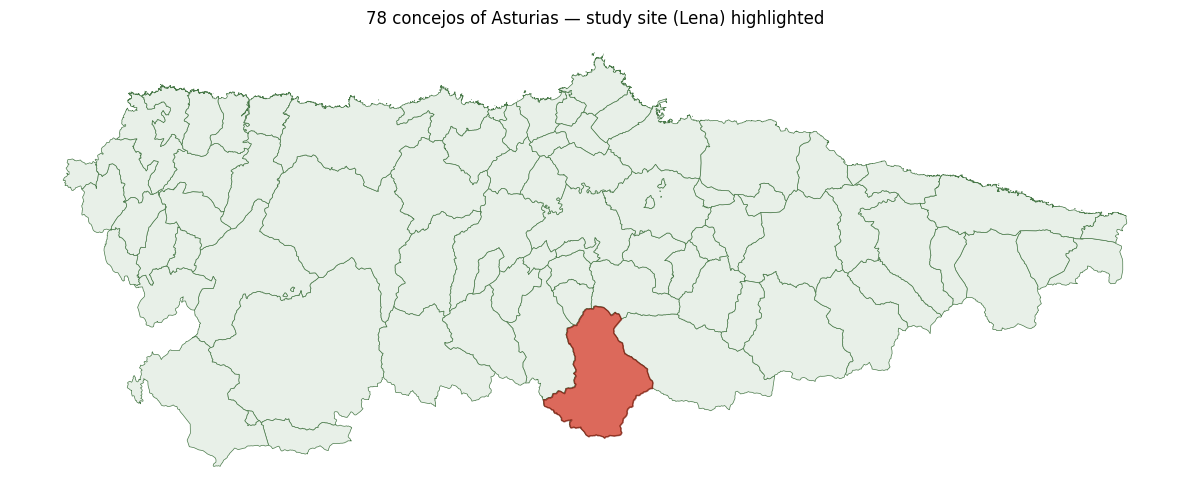

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

concejos.to_crs(CRS_MEASURE).plot(
    ax=ax, facecolor='#e8f0e8', edgecolor='#4a7a4a', linewidth=0.5)

# Highlight the concejo containing the study site.
concejos[concejos['adm3_name'].isin(STUDY_SITES)].to_crs(CRS_MEASURE).plot(
    ax=ax, facecolor='#d7301f', edgecolor='#7a1a0f', linewidth=1.0, alpha=0.7)

ax.set_title(f'{n} concejos of Asturias — study site (Lena) highlighted')
ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [ ]:
all_path = os.path.join(DATA_FOLDER, 'asturias_concejos.gpkg')
concejos.to_file(all_path)
print(f'Wrote {all_path}')

sites = concejos[concejos['adm3_name'].isin(STUDY_SITES)]
sites_path = os.path.join(DATA_FOLDER, 'study_sites_concejos.gpkg')
sites.to_file(sites_path)
print(f'Wrote {sites_path}   ({len(sites)} feature(s))')

Wrote /content/drive/MyDrive/asturias-grid-risk-ai/data/boundaries/asturias_concejos.gpkg
Wrote /content/drive/MyDrive/asturias-grid-risk-ai/data/boundaries/study_sites_concejos.gpkg   (1 feature(s))


In [ ]:
readme = f'''# Administrative boundaries — Asturias

- **Source URL:** {ADM3_URL}
- **Provider:** FieldMaps edge-matched, derived from geoBoundaries
- **Licence:** ODbL — attribution required, derived work under the same licence
- **Required attribution:** FieldMaps / geoBoundaries, ODbL
- **CRS:** {CRS_DELIVERY} as delivered
- **Retrieved:** {date.today().isoformat()}
- **Passport written:** {datetime.now(timezone.utc).isoformat(timespec="seconds")}

## Files

- `asturias_concejos.gpkg` — all {n} concejos of Asturias
- `study_sites_concejos.gpkg` — {", ".join(STUDY_SITES)} only

## Notes and assumptions

- adm3 in Spain = municipio. In Asturias municipios are named "concejos".
- Asturias is uniprovincial: adm1 and adm2 cover the same territory, so an adm2
  query returns one feature, not 78.
- Pajares is a village inside the concejo of Lena and does not exist at adm3
  level. The Lena polygon is used as its containing administrative unit.
- Boundaries from different providers (geoBoundaries, IGN, catastro) differ by
  tens of metres. This project uses geoBoundaries throughout and does not mix
  sources within one analysis.
- Total area verified at {area_km2:.0f} km2 in EPSG:25830 against a published
  figure of approximately {EXPECTED_AREA_KM2} km2.

---

Assumptions listed here also appear in `docs/ASSUMPTIONS.md` (A-01, A-02).
'''

readme_path = os.path.join(DATA_FOLDER, 'README.md')
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme)

print(f'Wrote {readme_path}\n')
print(readme)

Wrote /content/drive/MyDrive/asturias-grid-risk-ai/data/boundaries/README.md

# Administrative boundaries — Asturias

- **Source URL:** https://data.fieldmaps.io/edge-matched/open/intl/adm3_polygons.parquet
- **Provider:** FieldMaps edge-matched, derived from geoBoundaries
- **Licence:** ODbL — attribution required, derived work under the same licence
- **Required attribution:** FieldMaps / geoBoundaries, ODbL
- **CRS:** EPSG:4326 as delivered
- **Retrieved:** 2026-09-15
- **Passport written:** 2026-09-15T17:06:42+00:00

## Files

- `asturias_concejos.gpkg` — all 78 concejos of Asturias
- `study_sites_concejos.gpkg` — Lena only

## Notes and assumptions

- adm3 in Spain = municipio. In Asturias municipios are named "concejos".
- Asturias is uniprovincial: adm1 and adm2 cover the same territory, so an adm2
  query returns one feature, not 78.
- Pajares is a village inside the concejo of Lena and does not exist at adm3
  level. The Lena polygon is used as its containing administrative un